In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

In [61]:
#Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links (viel offener)
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",        # Gepunktet statt gestrichelt wirkt feiner
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})


--- Auswertung der Messungen ---
      Messung  Max Hub [µm]  Hysterese [%]
75 V (3.75 V)    659.060000      12.839875
   60 V (3 V)    578.900190      14.198295
   40 V (2 V)    421.113000      15.710671
 20 V (1.0 V)    189.706000      17.983770
  2 V (0.1 V)     12.781676      13.375153


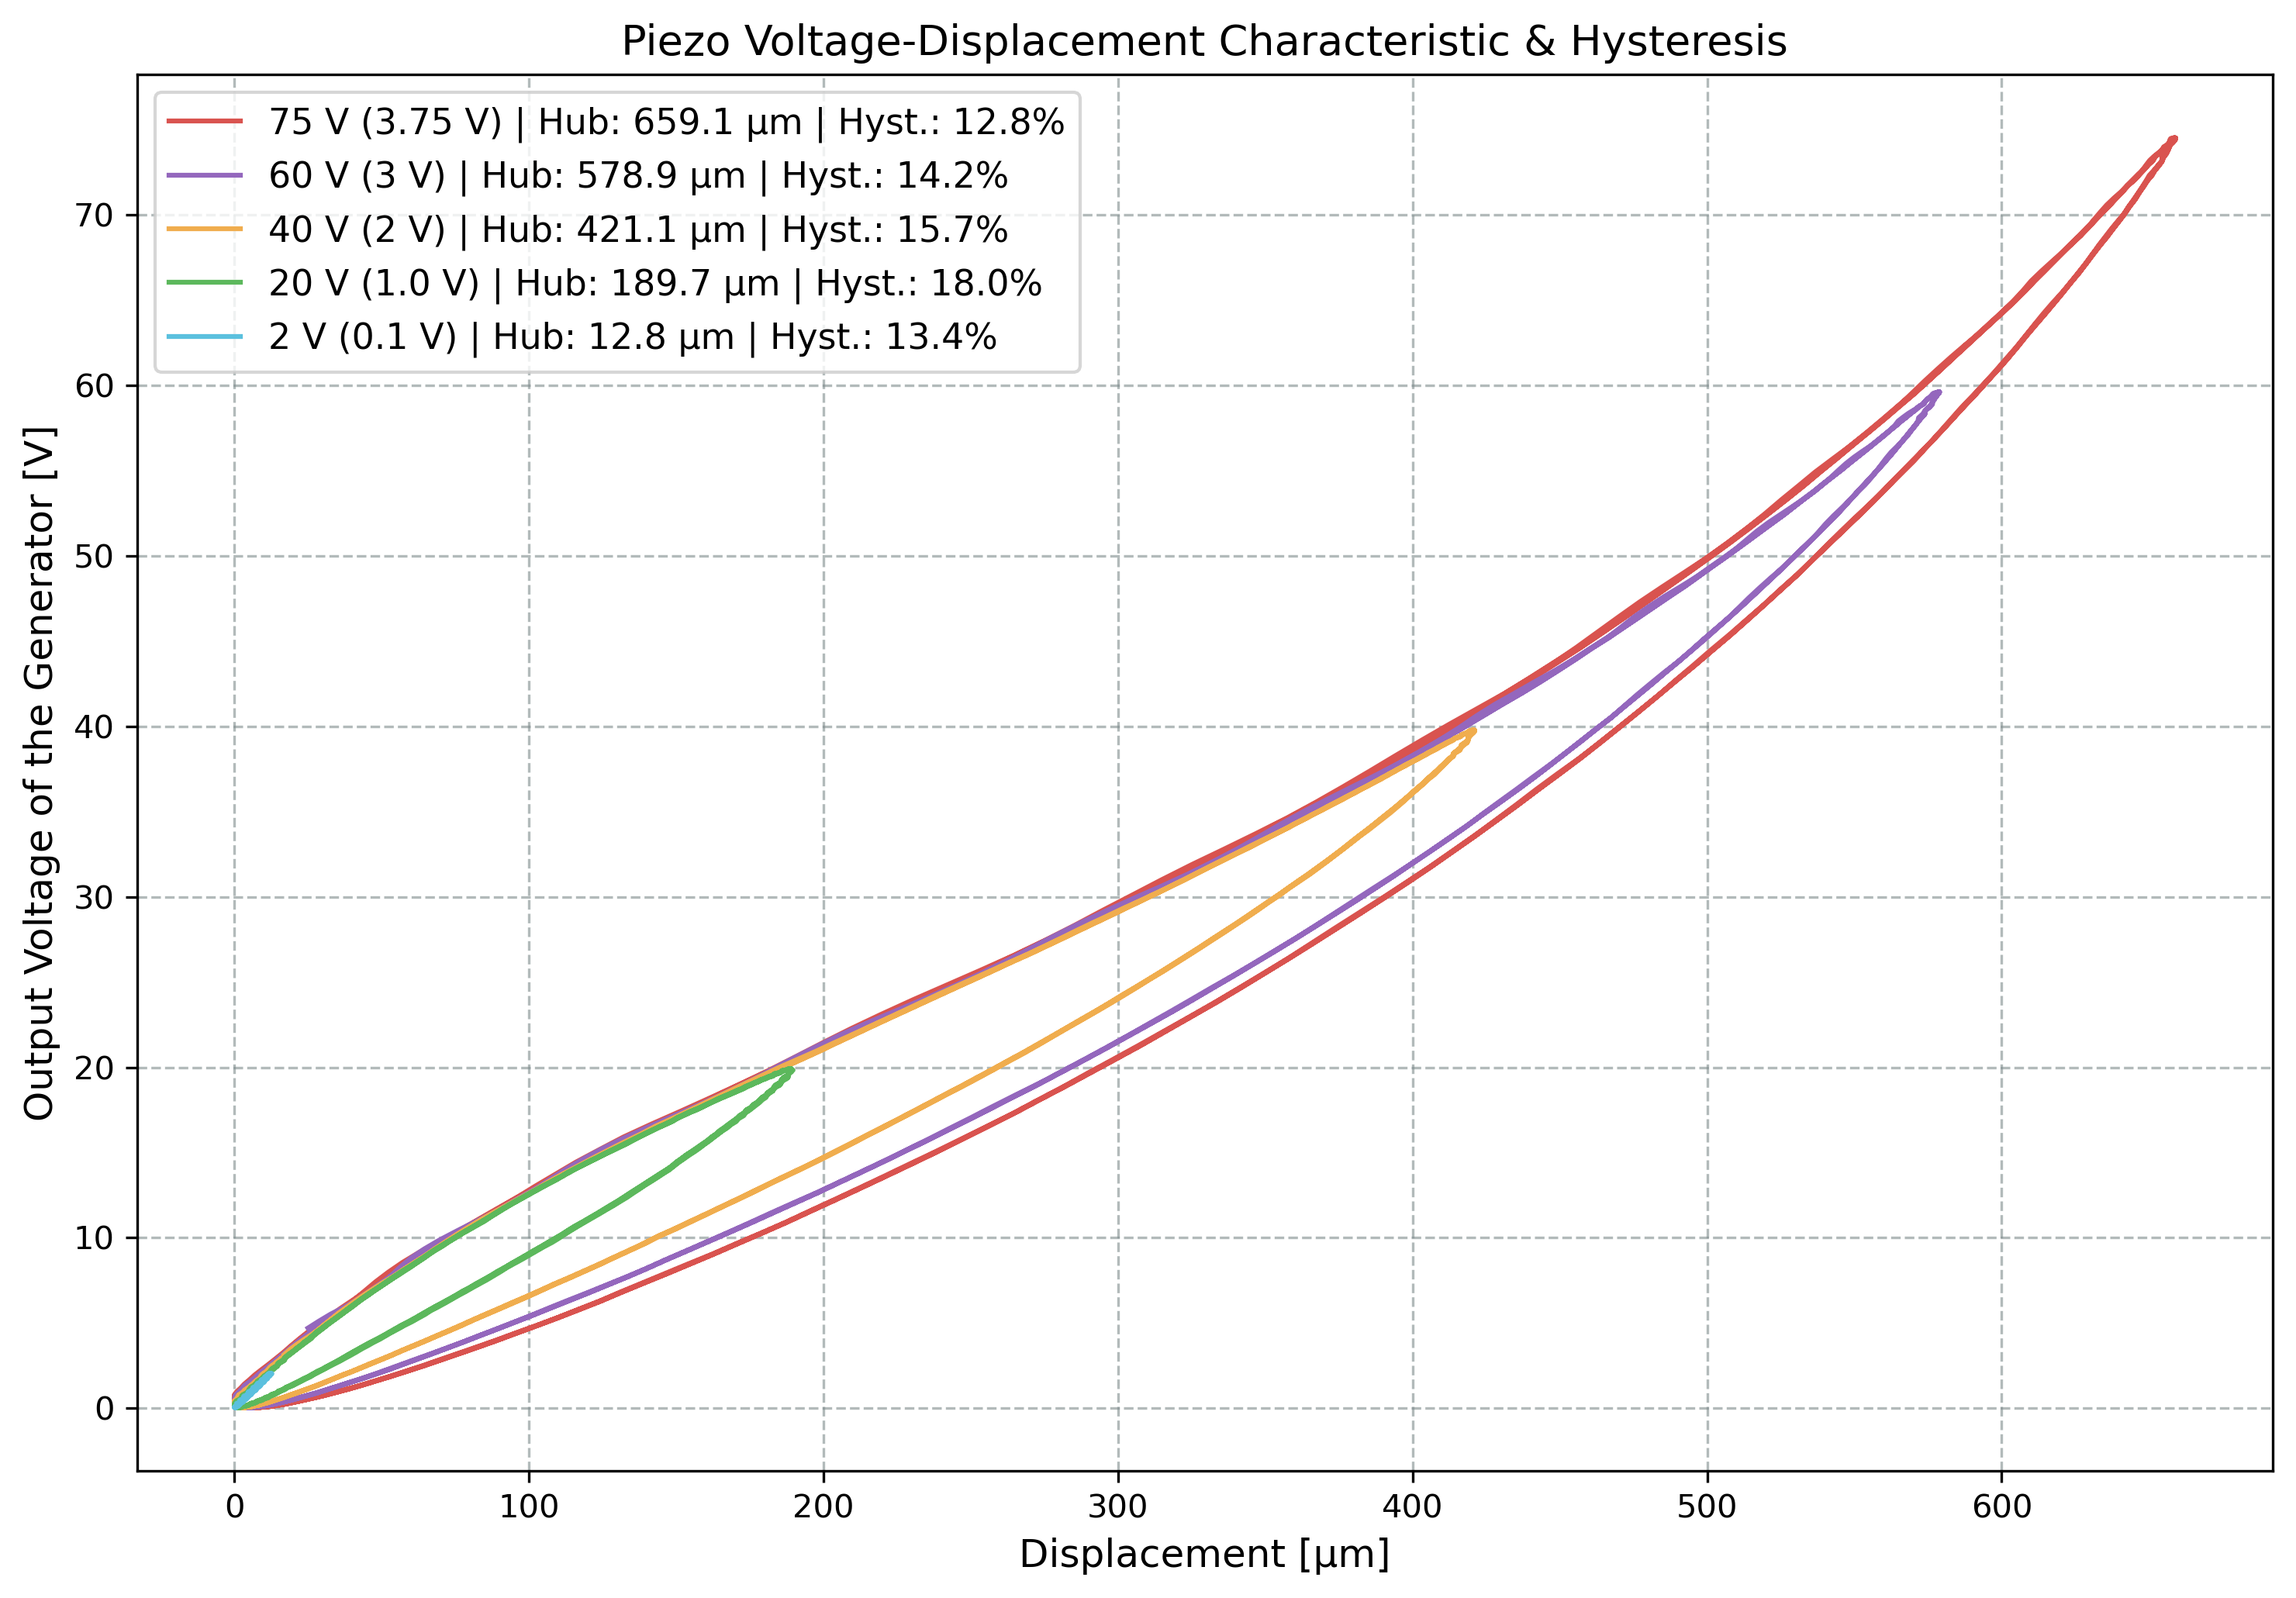

In [56]:
# Basisverzeichnis für die Messdateien
base_path = "/Users/trinity/Desktop/bachelor.thesis/measurements/piezo/"

# Konfiguration der Messungen inklusive der neuen 60V (3V) Messung
measurements = [
    {
        "name": "75 V (3.75 V)",
        "weg": "3,75weg.txt",
        "spannung": "3,75spannung.txt",
        "color": "#D9534F",
    },
    {
        "name": "60 V (3 V)",
        "weg": "3weg.txt",
        "spannung": "3spannung.txt",
        "color": "#9467BD",
    },
    {
        "name": "40 V (2 V)",
        "weg": "2weg.txt",
        "spannung": "2spannung.txt",
        "color": "#F0AD4E",
    },
    {
        "name": "20 V (1.0 V)",
        "weg": "1weg.txt",
        "spannung": "1spannung.txt",
        "color": "#5CB85C",
    },
    {
        "name": "2 V (0.1 V)",
        "weg": "0,1weg.txt",
        "spannung": "0,1spannung.txt",
        "color": "#5BC0DE",
    },
]

results = []
plot_data = []

# Einlesen und Auswerten aller Messungen
for m in measurements:
  try:
    file_w = base_path + m["weg"]
    file_s = base_path + m["spannung"]

    df_w = pd.read_csv(
        file_w, sep="\t", skiprows=5, header=None, names=["Zeit", "Weg"]
    )
    df_s = pd.read_csv(
        file_s, sep="\t", skiprows=5, header=None, names=["Zeit", "Spannung"]
    )

    df_w = df_w.apply(pd.to_numeric, errors="coerce")
    df_s = df_s.apply(pd.to_numeric, errors="coerce")
    df_m = pd.merge(df_w, df_s, on="Zeit")

    spannung = df_m["Spannung"].values * 10.0
    weg_raw = df_m["Weg"].values
    weg = weg_raw - np.min(weg_raw)
    max_weg = np.max(weg)
    weg_mum = 1000 * weg

    # Hysteresefehler in % berechnen (Hin- vs. Rückweg)
    peak_idx = np.argmax(weg)
    up_w, up_s = weg[:peak_idx], spannung[:peak_idx]
    down_w, down_s = weg[peak_idx:], spannung[peak_idx:]

    common_w = np.linspace(
        max(np.min(up_w), np.min(down_w)), min(np.max(up_w), np.max(down_w)), 200
    )
    up_f = interp1d(
        up_w, up_s, bounds_error=False, fill_value="extrapolate"
    )
    down_f = interp1d(
        down_w, down_s, bounds_error=False, fill_value="extrapolate"
    )

    max_diff = np.max(np.abs(up_f(common_w) - down_f(common_w)))
    total_span = np.max(spannung) - np.min(spannung)
    hysteresis_pct = (max_diff / total_span) * 100

    results.append(
        {
            "Messung": m["name"],
            "Max Hub [µm]": max_weg * 1000,
            "Hysterese [%]": hysteresis_pct,
        }
    )
    plot_data.append(
        {
            "name": m["name"],
            "weg_mum": weg_mum,
            "spannung": spannung,
            "color": m["color"],
            "max_hub": max_weg * 1000,
            "hysteresis": hysteresis_pct,
        }
    )

  except FileNotFoundError:
    print(f"Datei für {m['name']} nicht gefunden, übersprungen.")

# Ergebnisse in der Konsole ausgeben
df_res = pd.DataFrame(results)
print("\n--- Auswertung der Messungen ---")
print(df_res.to_string(index=False))

# ---------------------------------------------------------------------------
# Plotten aller Messungen in ein einziges Diagramm
# ---------------------------------------------------------------------------
plt.figure(figsize=(10, 7))

for data in plot_data:
  plt.plot(
      data["weg_mum"],
      data["spannung"],
      color=data["color"],
      label=f"{data['name']} | Hub: {data['max_hub']:.1f} µm | Hyst.: {data['hysteresis']:.1f}%",
  )

# Diagramm-Beschriftungen und Layout
plt.title("Piezo Voltage-Displacement Characteristic & Hysteresis")
plt.xlabel("Displacement [µm]")
plt.ylabel("Output Voltage of the Generator [V]")
plt.legend(loc="upper left", frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# Diagramm anzeigen
plt.show()


--- Measurement Summary ---
  Measurement  Max Stroke [µm]
75 V (3.75 V)       659.060000
   60 V (3 V)       578.900190
   40 V (2 V)       421.113000
 20 V (1.0 V)       189.706000
  2 V (0.1 V)        12.781676


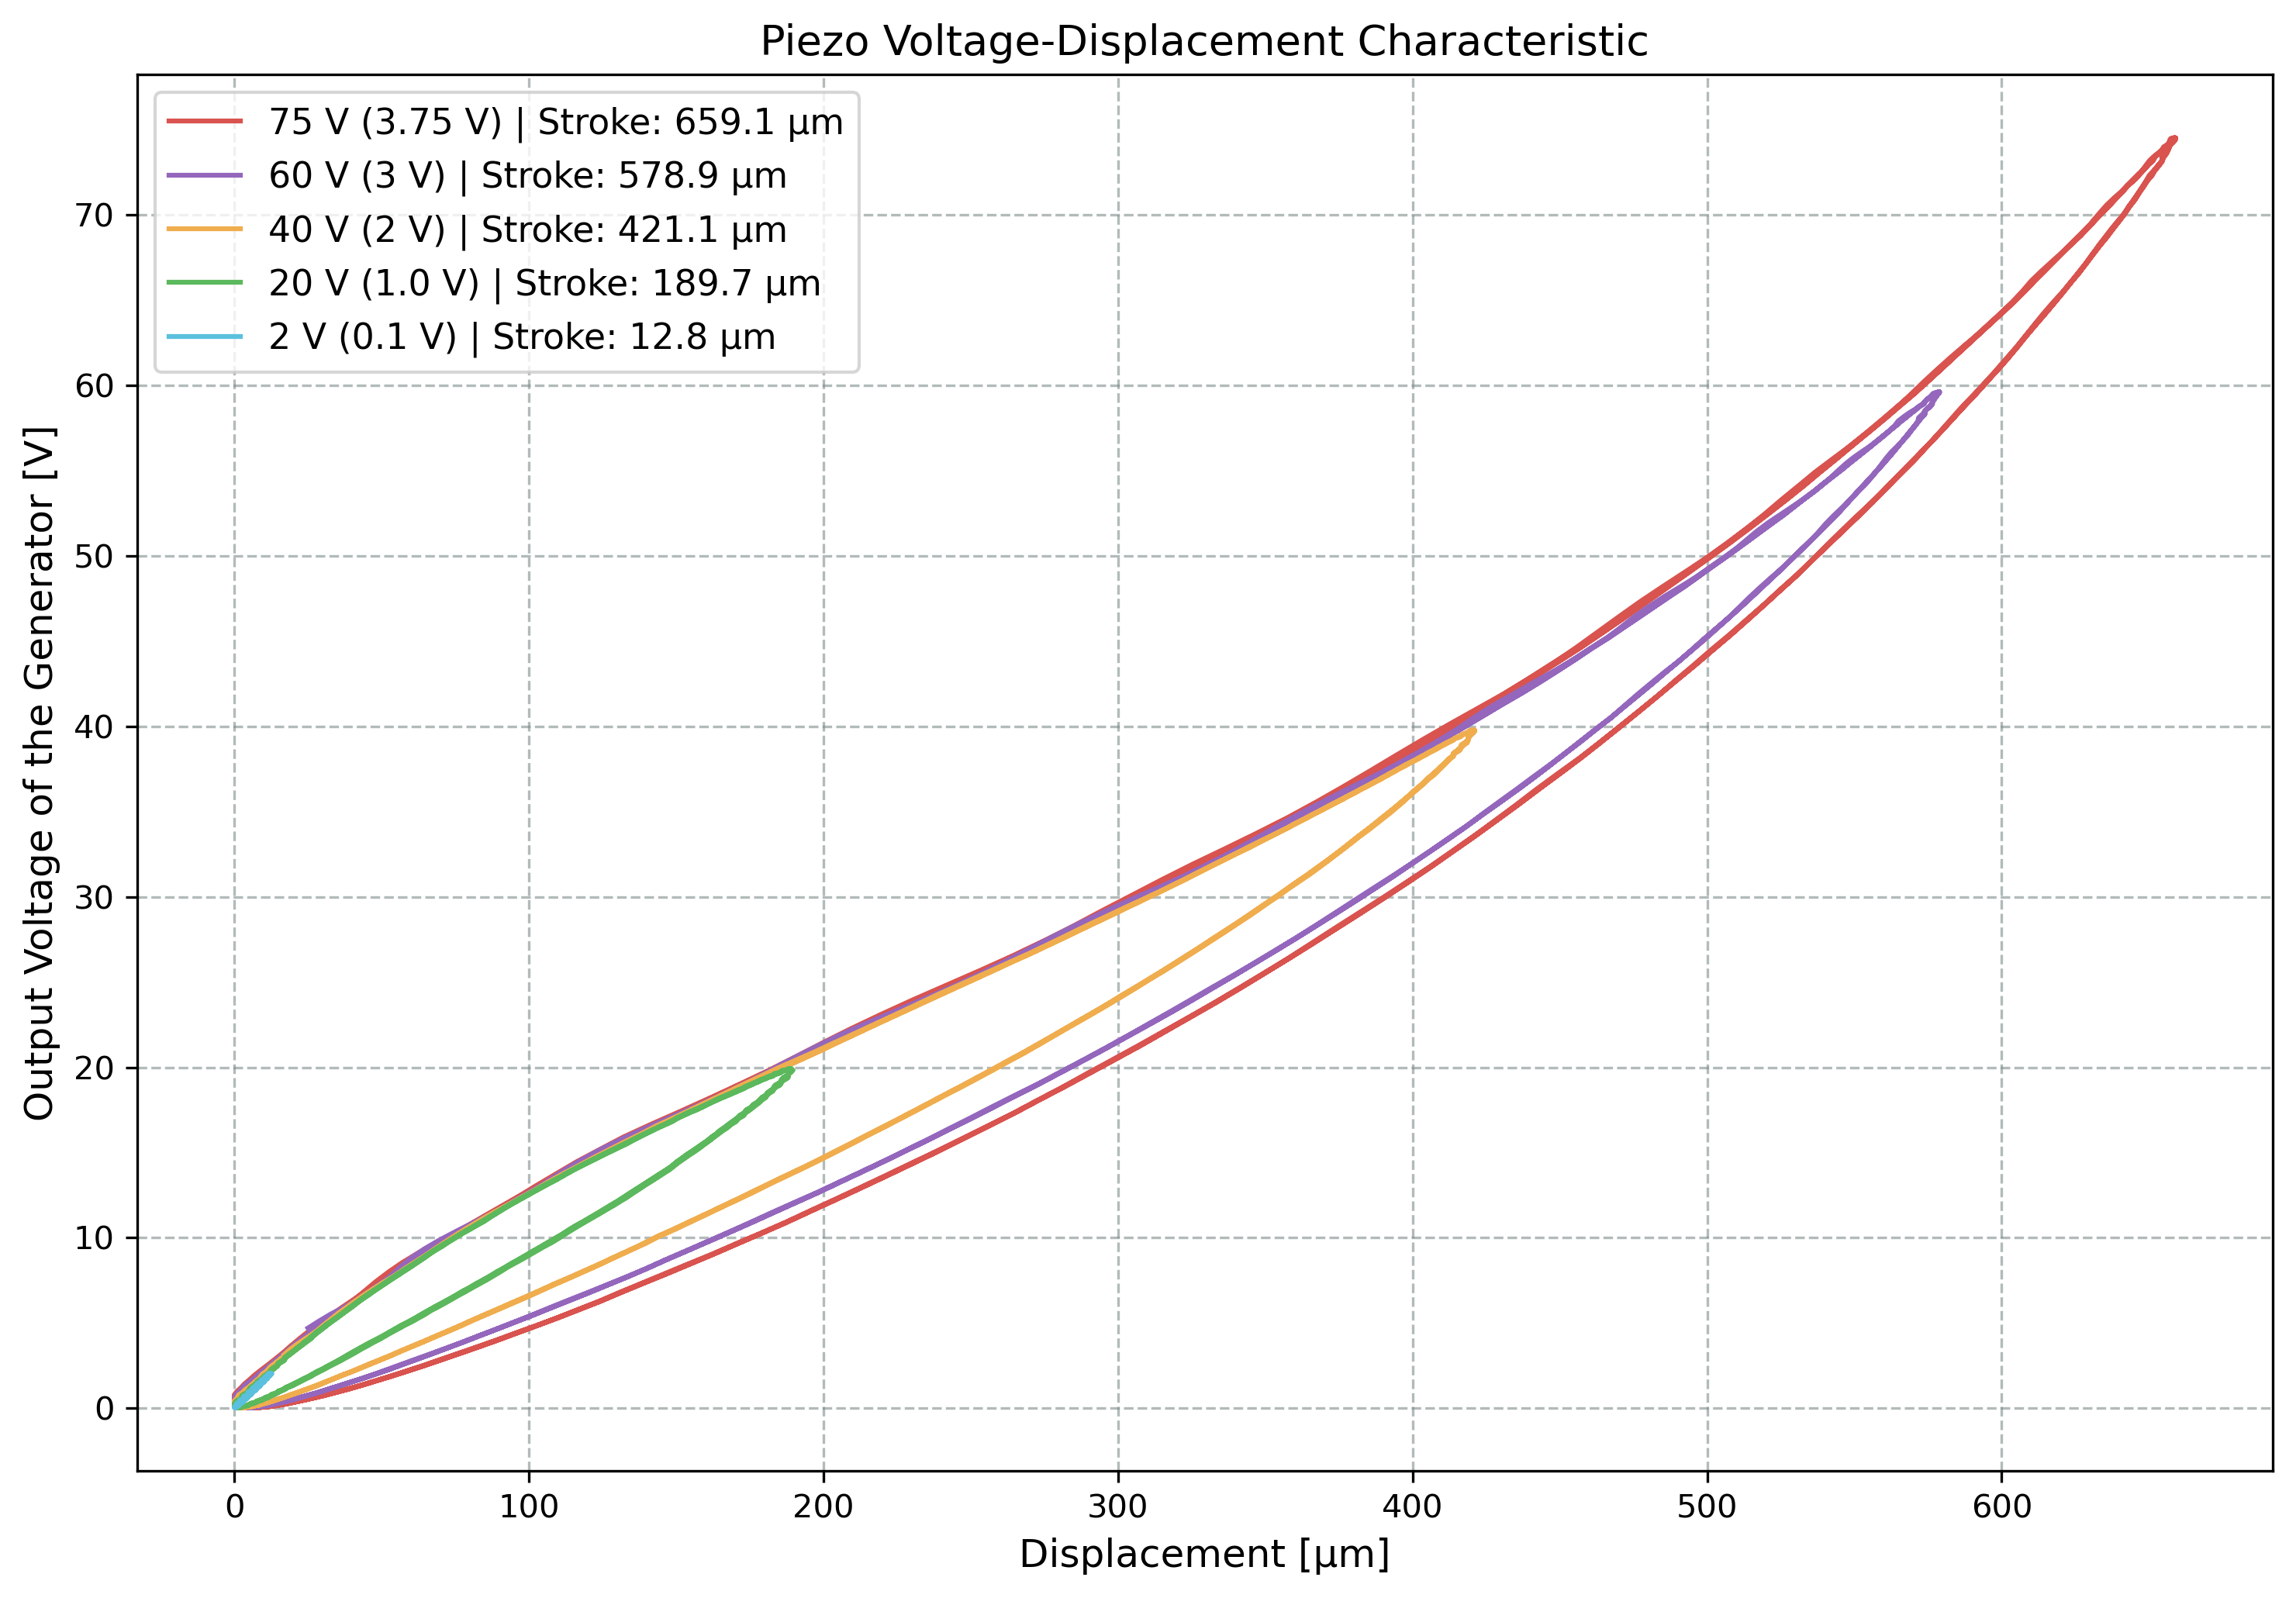

In [62]:
# Basisverzeichnis für die Messdateien
base_path = "/Users/trinity/Desktop/bachelor.thesis/measurements/piezo/"

# Konfiguration der Messungen auf Englisch (ohne Hysterese in der Legende)
measurements = [
    {
        "name": "75 V (3.75 V)",
        "weg": "3,75weg.txt",
        "spannung": "3,75spannung.txt",
        "color": "#D9534F",
    },
    {
        "name": "60 V (3 V)",
        "weg": "3weg.txt",
        "spannung": "3spannung.txt",
        "color": "#9467BD",
    },
    {
        "name": "40 V (2 V)",
        "weg": "2weg.txt",
        "spannung": "2spannung.txt",
        "color": "#F0AD4E",
    },
    {
        "name": "20 V (1.0 V)",
        "weg": "1weg.txt",
        "spannung": "1spannung.txt",
        "color": "#5CB85C",
    },
    {
        "name": "2 V (0.1 V)",
        "weg": "0,1weg.txt",
        "spannung": "0,1spannung.txt",
        "color": "#5BC0DE",
    },
]

results = []
plot_data = []

# Einlesen und Auswerten aller Messungen
for m in measurements:
  try:
    file_w = base_path + m["weg"]
    file_s = base_path + m["spannung"]

    df_w = pd.read_csv(
        file_w, sep="\t", skiprows=5, header=None, names=["Zeit", "Weg"]
    )
    df_s = pd.read_csv(
        file_s, sep="\t", skiprows=5, header=None, names=["Zeit", "Spannung"]
    )

    df_w = df_w.apply(pd.to_numeric, errors="coerce")
    df_s = df_s.apply(pd.to_numeric, errors="coerce")
    df_m = pd.merge(df_w, df_s, on="Zeit")

    spannung = df_m["Spannung"].values * 10.0
    weg_raw = df_m["Weg"].values
    weg = weg_raw - np.min(weg_raw)
    max_weg = np.max(weg)
    weg_mum = 1000 * weg

    results.append(
        {
            "Measurement": m["name"],
            "Max Stroke [µm]": max_weg * 1000,
        }
    )
    plot_data.append(
        {
            "name": m["name"],
            "weg_mum": weg_mum,
            "spannung": spannung,
            "color": m["color"],
            "max_hub": max_weg * 1000,
        }
    )

  except FileNotFoundError:
    print(f"File for {m['name']} not found, skipped.")

# Ergebnisse in der Konsole ausgeben
df_res = pd.DataFrame(results)
print("\n--- Measurement Summary ---")
print(df_res.to_string(index=False))

# ---------------------------------------------------------------------------
# Plotten aller Messungen in ein einziges Diagramm (komplett auf Englisch)
# ---------------------------------------------------------------------------
plt.figure(figsize=(10, 7))

for data in plot_data:
  plt.plot(
      data["weg_mum"],
      data["spannung"],
      color=data["color"],
      label=f"{data['name']} | Stroke: {data['max_hub']:.1f} µm",
  )

# Diagramm-Beschriftungen und Layout auf Englisch
plt.title("Piezo Voltage-Displacement Characteristic")
plt.xlabel("Displacement [µm]")
plt.ylabel("Output Voltage of the Generator [V]")
plt.legend(loc="upper left", frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# Optional: Diagramm direkt als Bild abspeichern
plt.savefig("/Users/trinity/Desktop/bachelor.thesis/measurements/piezo/piezo_characteristic.png")

# Diagramm anzeigen
plt.show()